# Phishing Feature Inspection & XGBoost False Positive Debugging

This Jupyter Notebook serves as a **supporting environment** for deeply inspecting the extracted features used by a deployed **XGBoost classification model**. Its primary goal is to **diagnose high False Positive Rates (FPR)**, specifically by analyzing the distribution and characteristics of features for data points incorrectly flagged as phishing (False Positives) versus truly benign data points.

## Imports


In [13]:
from __future__ import annotations

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Iterable, List, Tuple


In [8]:
# Tweak some matplotlib defaults for clarity
plt.rcParams.update({
    "figure.figsize": (14, 12),
    "axes.grid": True,
    "grid.alpha": 0.5,
    "grid.linewidth": 0.3,
})

## 1. Load the dataframe

In [ ]:
# The file path of the saved CSV file
file_path = Path('./dataframes/phishing_extracted_features.csv')

try:
    df = pd.read_csv(file_path)
    df.head()

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Ensure the saving step was executed.")

except Exception as e:
    print(f"An unexpected error occurred: {e}")

## 2. Visualize the distributions for critical features

In [15]:
# === Configuration ===
# Expecting a DataFrame named `df` to already exist in memory.

LABEL_COL = "label"  # change if needed
FEATURES: List[str] = [
    "rdap_domain_age",
    "lex_tld_abuse_score",
    "rdap_registrar_name_len",
    "tls_leaf_cert_validity_len",
    "rdap_domain_active_time",
    "tls_root_authority_hash",
    "lex_tld_len",
    "rdap_registrar_name_entropy",
    "tls_critical_extensions",
    "tls_percentage_crt_with_policies",
]

# If your labels are strings such as "phishing"/"benign", leave these as None to auto-detect.
PHISHING_LABEL = None  # e.g., 1 or "phishing"
BENIGN_LABEL   = None  # e.g., 0 or "benign"

# Histogram bins (you can reduce to 30 if you have fewer rows)
BINS = 50

# Automatically use log-x for highly right-skewed, non-negative features
LOG_IF_SKEWED = False

In [10]:

def infer_labels(df: pd.DataFrame, label_col: str, phishing_label=None, benign_label=None) -> Tuple[object, object]:
    """Infer phishing/benign label values from the dataframe if not provided.
    
    Prefers 1/0 or 'phishing'/'benign'. If still ambiguous, uses the two most
    frequent classes and assumes the most frequent is benign.
    """
    if phishing_label is not None and benign_label is not None:
        return phishing_label, benign_label

    labels = df[label_col].dropna().unique().tolist()
    s = set(labels)
    lower = {str(x).lower(): x for x in labels}

    if s == {0, 1} or s == {1, 0}:
        return 1, 0
    if "phishing" in lower and "benign" in lower:
        return lower["phishing"], lower["benign"]

    vc = df[label_col].value_counts()
    if len(vc) >= 2:
        # most common => benign, second most => phishing (heuristic)
        return vc.index[1], vc.index[0]
    # fallback: just return the only class twice (plots will warn/skips)
    return labels[0], labels[0]


def numeric_series(s: pd.Series) -> pd.Series:
    """Coerce a series to numeric, dropping NaNs."""
    return pd.to_numeric(s, errors="coerce").dropna()


def is_heavily_skewed(values: np.ndarray) -> bool:
    """Simple right-skew check using 95th/5th percentile ratio."""
    if values.size == 0:
        return False
    q5, q95 = np.percentile(values, [5, 95])
    # Avoid divide-by-zero
    q5 = q5 if abs(q5) > 1e-12 else 1e-12
    return q95 > 10 * q5 and np.all(values >= 0)


def label_counts(df: pd.DataFrame, label_col: str) -> pd.Series:
    """Return counts of each label value, including NaN as a category."""
    return df[label_col].value_counts(dropna=False)


In [11]:

def plot_numeric_distributions(
    df: pd.DataFrame,
    features: Iterable[str],
    label_col: str,
    phishing_label,
    benign_label,
    bins: int = 50,
    log_if_skewed: bool = True,
    n_rows: int | None = None,
    n_cols: int | None = None,
) -> None:
    """Plot overlaid normalized histograms for phishing vs benign for numeric features.
    
    Non-numeric or all-NaN features are skipped with a console message.
    """
    features = [f for f in features if f in df.columns]
    if not features:
        print("[Warn] None of the requested features are in the dataframe.")
        return

    ph = df[df[label_col] == phishing_label]
    be = df[df[label_col] == benign_label]

    # grid size
    k = len(features)
    if n_rows is None or n_cols is None:
        n_rows = math.ceil(k / 2)
        n_cols = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, max(8, 2.4 * n_rows)))
    axes = np.array(axes).reshape(-1)  # flatten safely

    idx = 0
    skipped: List[str] = []
    for feat in features:
        if idx >= len(axes):
            break
        ax = axes[idx]
        idx += 1

        x_be = numeric_series(be[feat])
        x_ph = numeric_series(ph[feat])

        # If both are empty after coercion, consider it non-numeric or all-NaN
        if x_be.size == 0 and x_ph.size == 0:
            ax.set_visible(False)
            skipped.append(feat)
            continue

        # Optional log-x for highly skewed, non-negative distributions
        if log_if_skewed:
            allx = np.concatenate([x for x in (x_be.values, x_ph.values) if x.size > 0])
            if is_heavily_skewed(allx):
                ax.set_xscale("log")

        if x_be.size:
            ax.hist(x_be, bins=bins, density=True, alpha=0.5, label="Benign", edgecolor="none")
        if x_ph.size:
            ax.hist(x_ph, bins=bins, density=True, alpha=0.5, label="Phishing", edgecolor="none")

        ax.set_title(feat)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8)

    # Hide any leftover axes
    for j in range(idx, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Feature Distributions: Phishing vs Benign", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

    if skipped:
        print("[Skipped (non-numeric or all-NaN)]:", ", ".join(skipped))


def plot_top_categories_side_by_side(
    df: pd.DataFrame,
    feat: str,
    label_col: str,
    phishing_label,
    benign_label,
    top_n: int = 10,
) -> None:
    """Bar charts of top-N categories per class shown side-by-side."""
    ph = df[df[label_col] == phishing_label]
    be = df[df[label_col] == benign_label]

    ph_counts = ph[feat].astype(str).value_counts().head(top_n)
    be_counts = be[feat].astype(str).value_counts().head(top_n)

    fig = plt.figure(figsize=(14, 4))
    ax1 = plt.subplot(1, 2, 1)
    ph_counts.plot(kind="bar", ax=ax1)
    ax1.set_title(f"{feat} (Phishing, top {top_n})")
    ax1.tick_params(axis="x", labelrotation=45)
    ax1.set_ylabel("Count")

    ax2 = plt.subplot(1, 2, 2)
    be_counts.plot(kind="bar", ax=ax2)
    ax2.set_title(f"{feat} (Benign, top {top_n})")
    ax2.tick_params(axis="x", labelrotation=45)
    ax2.set_ylabel("Count")

    fig.tight_layout()
    plt.show()


Label counts:
 label
benign      816324
phishing    164425
Name: count, dtype: int64
Using labels -> phishing='phishing', benign='benign'


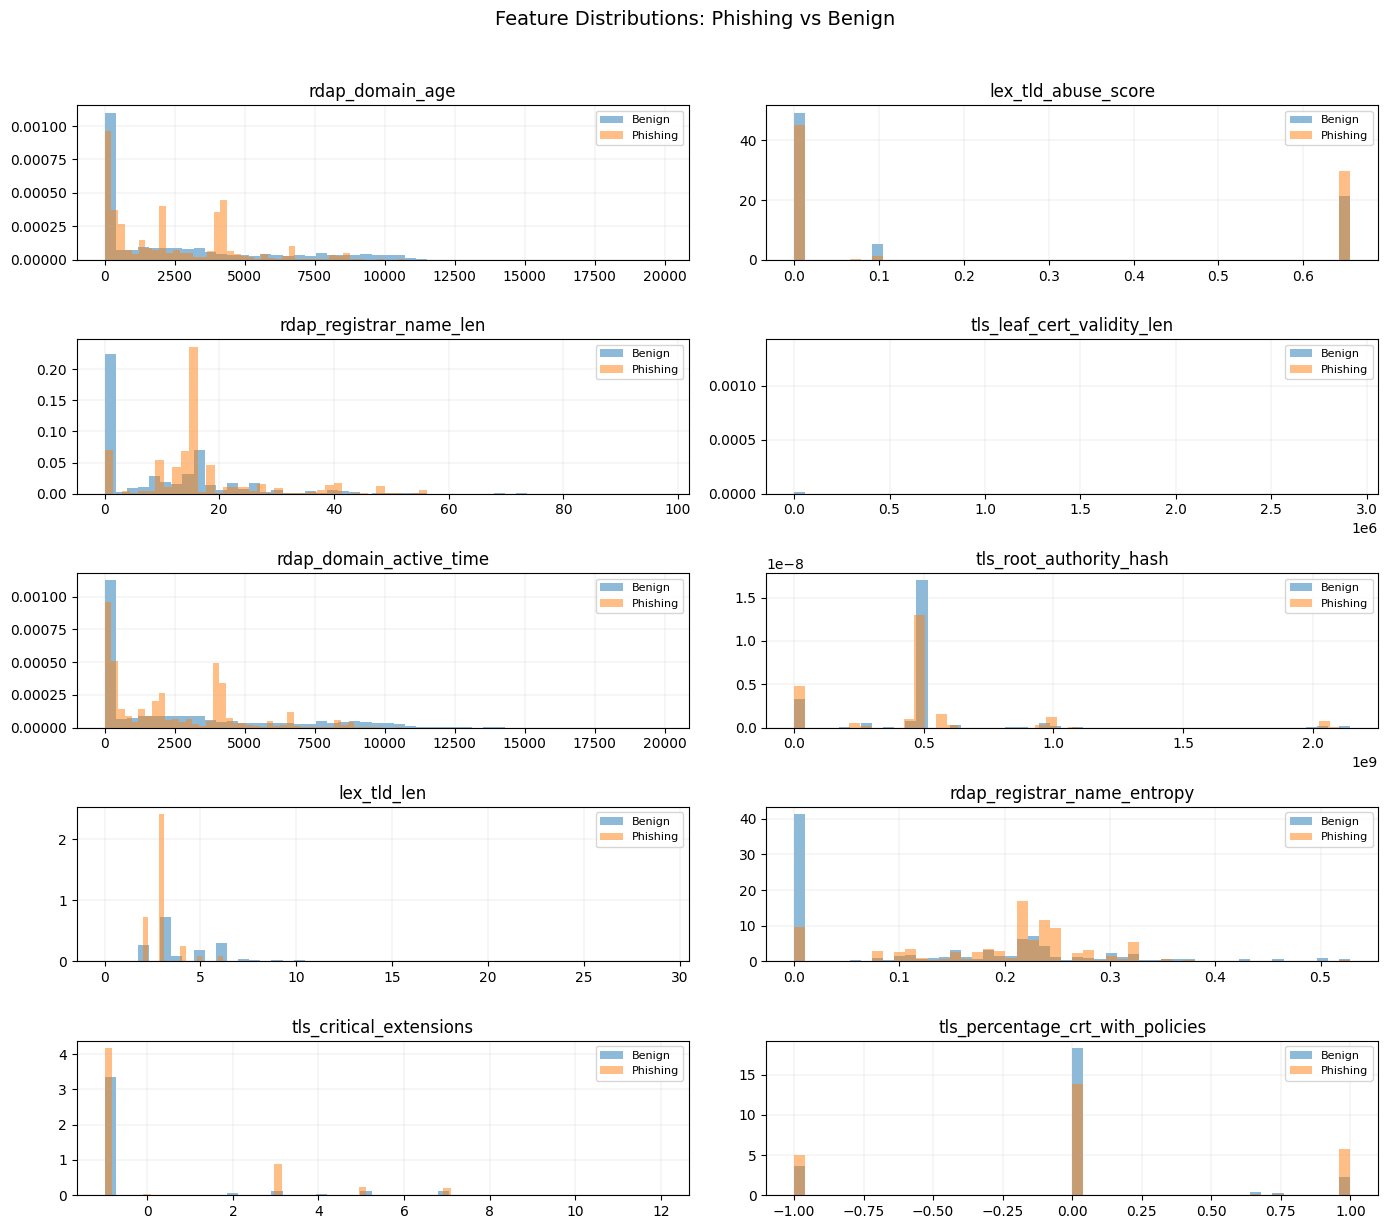

In [16]:

# === Quick sanity check ===
print("Label counts:\n", label_counts(df, LABEL_COL))

PH, BE = infer_labels(df, LABEL_COL, PHISHING_LABEL, BENIGN_LABEL)
print(f"Using labels -> phishing={PH!r}, benign={BE!r}")

# === Main numeric plots ===
plot_numeric_distributions(
    df,
    FEATURES,
    label_col=LABEL_COL,
    phishing_label=PH,
    benign_label=BE,
    bins=BINS,
    log_if_skewed=LOG_IF_SKEWED,
)

# === (Optional) categorical example ===
# If a column like 'tls_root_authority_hash' is categorical (skipped above), you can run:
# plot_top_categories_side_by_side(df, "tls_root_authority_hash", LABEL_COL, PH, BE, top_n=10)


## 3. Analyzing TLS_LEAF_CERT_VALIDITY_LEN

dtype=float64  |  coerced_non_numeric=0  |  NaN=0
<=0 count: 834156

Overall quantiles:
           value
0.000       -1.0
0.001       -1.0
0.010       -1.0
0.050       -1.0
0.250       -1.0
0.500       -1.0
0.750       -1.0
0.950      395.0
0.990      397.0
0.999     7300.0
1.000  2913556.0

Per-class quantiles:
     benign  phishing
p05     NaN       NaN
p25     NaN       NaN
p50     NaN       NaN
p75     NaN       NaN
p95     NaN       NaN
p99     NaN       NaN

Smallest 5 values:


,label,tls_leaf_cert_validity_len
0,benign,-1.0
1,benign,-1.0
2,benign,-1.0
3,benign,-1.0
4,benign,-1.0



Largest 5 values:


,label,tls_leaf_cert_validity_len
11343,benign,2913556.0
11349,benign,2913556.0
11357,benign,2913556.0
284685,benign,999999.0
333915,benign,999999.0


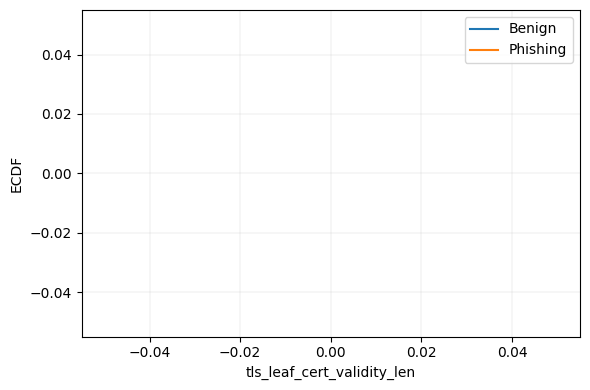

In [17]:
FEATURE = "tls_leaf_cert_validity_len"
LABEL   = "label"        # change if needed
PHISH   = 1              # or "phishing"
BENIGN  = 0              # or "benign"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Basic type & missingness
s_raw = df[FEATURE]
s = pd.to_numeric(s_raw, errors="coerce")
print(f"dtype={s_raw.dtype}  |  coerced_non_numeric={s_raw.shape[0]-s.notna().sum()}  |  NaN={s.isna().sum()}")
print(f"<=0 count: {(s<=0).sum()}")

# 2) Overall percentiles (helps see if a few huge values stretch the axis)
q = s.quantile([0, .001, .01, .05, .25, .5, .75, .95, .99, .999, 1.0], interpolation="linear")
print("\nOverall quantiles:")
print(q.to_frame("value"))

# 3) Per-class percentiles
def pctiles(x):
    return x.quantile([.05,.25,.5,.75,.95,.99], interpolation="linear").rename(index={
        .05:"p05", .25:"p25", .5:"p50", .75:"p75", .95:"p95", .99:"p99"
    })

print("\nPer-class quantiles:")
print(pd.concat({
    "benign": pctiles(pd.to_numeric(df.loc[df[LABEL]==BENIGN, FEATURE], errors="coerce")),
    "phishing": pctiles(pd.to_numeric(df.loc[df[LABEL]==PHISH, FEATURE], errors="coerce")),
}, axis=1))

# 4) Show extreme rows (to inspect actual records/units)
print("\nSmallest 5 values:")
display(df.loc[s.nsmallest(5).index, [LABEL, FEATURE]].head())

print("\nLargest 5 values:")
display(df.loc[s.nlargest(5).index, [LABEL, FEATURE]].head())

# 5) Quick ECDF overlay (more honest than hist when there are huge ranges)
def ecdf(x):
    x = np.asarray(x.dropna())
    x = np.sort(x)
    y = np.arange(1, x.size+1)/x.size
    return x, y

ph = pd.to_numeric(df.loc[df[LABEL]==PHISH, FEATURE], errors="coerce").dropna()
be = pd.to_numeric(df.loc[df[LABEL]==BENIGN, FEATURE], errors="coerce").dropna()

plt.figure(figsize=(6,4))
xb, yb = ecdf(be); plt.plot(xb, yb, label="Benign")
xp, yp = ecdf(ph); plt.plot(xp, yp, label="Phishing")
plt.xlabel(FEATURE); plt.ylabel("ECDF"); plt.legend(); plt.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout(); plt.show()

# Optional: log-x ECDF if values are non-negative and super skewed
if (s>=0).all():
    plt.figure(figsize=(6,4))
    xb, yb = ecdf(be[be>0]); plt.plot(xb, yb, label="Benign")
    xp, yp = ecdf(ph[ph>0]); plt.plot(xp, yp, label="Phishing")
    plt.xscale("log"); plt.xlabel(FEATURE + " (log)"); plt.ylabel("ECDF"); plt.legend(); plt.grid(True, linewidth=0.3, alpha=0.5)
    plt.tight_layout(); plt.show()


In [18]:
FEATURE = "tls_leaf_cert_validity_len"
LABEL   = "label"   # change if needed

# Boolean mask for "no certificate"
no_cert = df[FEATURE] <= 0

# Overall
n_missing = int(no_cert.sum())
pct_missing = float(no_cert.mean())
print(f"No-cert rows: {n_missing:,}  ({pct_missing:.1%})")

# By class
by_class = (
    df.assign(no_cert=no_cert)
      .groupby(LABEL)["no_cert"]
      .agg(missing="sum", total="count", rate="mean")
      .sort_values("rate", ascending=False)
)
print(by_class)

# (Optional) keep a learnable indicator feature
df[FEATURE + "_missing"] = no_cert.astype(int)


No-cert rows: 834,156  (85.1%)
          missing   total      rate
label                              
benign     711074  816324  0.871068
phishing   123082  164425  0.748560


In [19]:
import numpy as np
import pandas as pd

LABEL   = "label"
PHISH   = "phishing"
BENIGN  = "benign"
FEATURE = "tls_leaf_cert_validity_len"

# 1) Build the missingness indicator (<=0 means no cert in your data)
no_cert = (df[FEATURE] <= 0).astype(int)

# 2) Contingency table
ct = pd.crosstab(df[LABEL], no_cert)  # columns: 0=has cert, 1=no cert
ct.columns = ["has_cert","no_cert"]
print("Contingency table:\n", ct, "\n")

# Extract counts: a,b,c,d for odds ratio and chi-square
#   a = phishing & no_cert, b = phishing & has_cert
#   c = benign   & no_cert, d = benign   & has_cert
a = int(ct.loc[PHISH,  "no_cert"]) if PHISH  in ct.index else 0
b = int(ct.loc[PHISH,  "has_cert"]) if PHISH  in ct.index else 0
c = int(ct.loc[BENIGN, "no_cert"]) if BENIGN in ct.index else 0
d = int(ct.loc[BENIGN, "has_cert"]) if BENIGN in ct.index else 0

# 3) Rates and gap
rate_phish  = a / (a + b) if (a+b) else np.nan
rate_benign = c / (c + d) if (c+d) else np.nan
gap = rate_phish - rate_benign
print(f"no-cert rate: phishing={rate_phish:.3f}, benign={rate_benign:.3f}, gap={gap:+.3f}")

# 4) Odds ratio (with 95% CI) and chi-square (Yates)
eps = 0.5  # Haldane-Anscombe correction in case of zeros
OR  = ((a+eps)*(d+eps))/((b+eps)*(c+eps))
se  = np.sqrt(1/(a+eps) + 1/(b+eps) + 1/(c+eps) + 1/(d+eps))
lo, hi = np.exp(np.log(OR) - 1.96*se), np.exp(np.log(OR) + 1.96*se)
print(f"Odds ratio={OR:.2f}  (95% CI: {lo:.2f}–{hi:.2f})")

# Chi-square with Yates correction (df=1)
N = a+b+c+d
row1 = a+b; row2 = c+d
col1 = a+c; col2 = b+d
expected_a = row1*col1/N
chi_yates = (abs(a - expected_a) - 0.5)**2 / (expected_a*(1 - col1/N)*(1 - row1/N))
# Rough p-value from df=1 chi-square (good enough for quick check)
from math import exp
p_val = exp(-0.5*chi_yates)  # upper tail approx
print(f"Chi-square (Yates)≈{chi_yates:.2f}, p≈{p_val:.3g}")

# 5) Predictiveness: AUC using only the missingness flag
# (scores=1 for no-cert, 0 for has-cert)
from sklearn.metrics import roc_auc_score
labels01 = (df[LABEL] == PHISH).astype(int)
auc = roc_auc_score(labels01, no_cert)
print(f"AUC (missingness only) = {auc:.3f}")


Contingency table:
           has_cert  no_cert
label                      
benign      105250   711074
phishing     41343   123082 

no-cert rate: phishing=0.749, benign=0.871, gap=-0.123
Odds ratio=0.44  (95% CI: 0.44–0.45)
Chi-square (Yates)≈16155.94, p≈0
AUC (missingness only) = 0.439
